# Lab 7.01 - Time series analysis

In [34]:
# Package Imports
import numpy as np                                  # Scientific computing
import pandas as pd                                 # Dataframe manipulation
import scipy.stats as stats                         # Statistical tests
import matplotlib.pyplot as plt                     # Basic visualization
import seaborn as sns                               # Advanced data visualization
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

### Exercise 1 - House sales

The file House Sales.csv contains monthly data on the number of new one-family
houses sold in the United States (in thousands) from January 1991 through December 2011.
Housing sales were steadily trending upward until about the beginning of 2006, then the
bottom fell out of the housing market, and sales eventually started trending upward again.   

- First Create a time series chart of the data.
- Add predictions for Simple Moving Average with span of 3, 6 and 12 months to the dataframe.
- Add predictions for Simple Exponential Smooting to the dataframe.
- Add predictions for Double Exponential Smoothing to the dataframe.
- Calculate the MAE to find the best model

In [14]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Monthly%20House%20Sales.csv', delimiter = ";", date_format='%m/%y', parse_dates=['Month']).set_index(['Month'])
data.head()

,Houses Sold
Month,
jan/91,401
feb/91,482
mrt/91,507
apr/91,508
mei/91,517


First Create a time series chart of the data.

<Axes: xlabel='Month'>

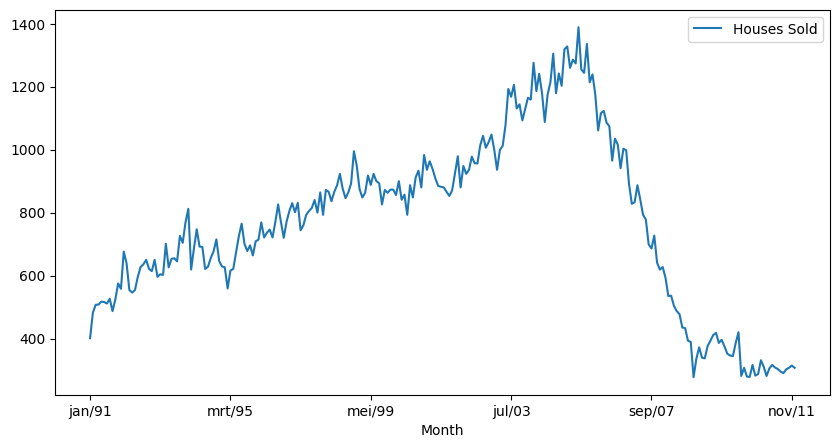

In [15]:
data.plot(y='Houses Sold', figsize=[10, 5])

Add predictions for Simple Moving Average with span of 3, 6 and 12 months to the dataframe.

In [51]:
data = data.drop(columns=['SMA3', 'SMA6', 'SMA12', 'SES', 'SES_predicted_value'])

In [52]:
for i in [3, 6, 12]:
    data[f'SMA{i}'] = data['Houses Sold'].rolling(i).mean().shift(1)
data.head(20)

,Houses Sold,SMA3,SMA6,SMA12
Month,,,,
jan/91,401,NaN,NaN,NaN
feb/91,482,NaN,NaN,NaN
mrt/91,507,NaN,NaN,NaN
apr/91,508,463.333333,NaN,NaN
mei/91,517,499.000000,NaN,NaN
jun/91,516,510.666667,NaN,NaN
jul/91,511,513.666667,488.500000,NaN
aug/91,526,514.666667,506.833333,NaN
sep/91,487,517.666667,514.166667,NaN


Add predictions for Simple Exponential Smooting to the dataframe.

In [56]:
train = data['Houses Sold'][:'dec/09']
test = data['Houses Sold']['jan/10':]

# train.tail()
# test.head()

In [54]:
# Fit SES model on complete series
data_ses = SimpleExpSmoothing(train).fit()
ses_forecast = data_ses.forecast(24)

/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/warrevl/D

Add predictions for Double Exponential Smoothing to the dataframe.

In [55]:
data_des = Holt(train).fit()
des_forecast = data_des.forecast(24)

/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/warrevl/Documents/2025-2026/Sem2/Data Science/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/warrevl/D

Calculate the MAE to find the best model. First drop the rows with NaN.

In [79]:
# MAE berekenen
# SMA3
y_true = test.values
y_predicted = data['SMA3'][-24:].values
mae_sma3 = mean_absolute_error(y_true, y_predicted)

# SMA6
y_predicted = data['SMA6'][-24:].values
mae_sma6 = mean_absolute_error(y_true, y_predicted)

# SMA12
y_predicted = data['SMA12'][-24:].values
mae_sma12 = mean_absolute_error(y_true, y_predicted)

# SES
y_predicted = ses_forecast.values
mae_ses = mean_absolute_error(y_true, y_predicted)

# DES
y_predicted = des_forecast.values
mae_des = mean_absolute_error(y_true, y_predicted)

print(f"MEA SMA3 = {mae_sma3}")
print(f"MEA SMA6 = {mae_sma6}")
print(f"MEA SMA12 = {mae_sma12}")
print(f"MEA SES = {mae_ses}")
print(f"MEA DES = {mae_des}")

MEA SMA3 = 23.944444444444443
MEA SMA6 = 25.1875
MEA SMA12 = 29.510416666666668
MEA SES = 55.83416417041343
MEA DES = 35.27314556185897


## Source
Business Analytics Data Analysis & Decision Making 